# Laboratorio 6
Alina Carías, Daniel Machic, Ariela Mishaan

**Github:** https://github.com/ArielaMishaanCohen/LAB6.git

## Task 1

### Ejercicio 1

#### Por qué una red tipo VGG de 150 capas fracasaría

El argumento de "más prfundo siempre es mejor" es intuitivo, pero incorrecto. Una red secuencial VGGde 150 capas fallaría por dos razones:

**1. Desvanecimiento del gradiente**
Durante el entrenamiento, los pesos se actualizan usando backpropagation:

$$\Delta w = -\eta \frac{\partial{J}}{\partial{w}}$$

donde J es la función de pérdida, w los pesos y $\eta$ el learning rate.

El gradiente, mientras más capas lleve la red neuronal, es un producto de más derivadas. Si se usan activaciones como ReLU o funciones con derivadas menores que 1, el resultado de la multiplicación será cada vez más cercano a cero. Por eso se le llama "vanishing gradient". Cuando la red es muy profunda, los pesos terminan siendo 0 en las últimas capas, lo que provoca que la red ya no siga aprendiendo. El entrenamiento se vuelve muy lento y el modelo se estanca.

**2. Fenómeno de degradación**

Teóricamente, al agregar más capas, el error de entrenamiento no debería empeorar, porque las nuevas capas podrían aprender la identidad:

$$H(x) = x$$

Sin embargo, en redes profundas secuenciales ocurre lo contrario. Al aumentar la profundidad, el error de entrenamiento aumenta. El modelo profundo rinde peor que uno menos profundo, no por sobreajuste, sino por problema de optimización. Esto pasa porque la red debe aprender directamente una función compleja: $H(x)$, y al aumentar capas, el espacio de optimización se vuelve más difícil de recorrer.

**Conclusión:** entrenar una VGG-150 sería inestable, muy costoso, propenso a colapsar y no funcionaría

#### Cómo ResNet rescata el proyecto

ResNet introduce una modificación a la estructura:

$$y = F(x) + x$$

En lugar de aprender directamente $H(x)$, la red aprende el residuo:

$$F(x) = H(x) - x$$

Ahora el gradiente en backpropagation no tiende a 0:

$$\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + 1$$

Gracias al +1, el gradiente no desaparece, als capas siguen aprendiendo y la red puede ser profunda.

Además, el problema de optimización se vuelve más fácil. Si la función óptima es cercana a la identidad, ahora la red solo debe aprender $F(x) \sim 0$, qeu es más sencillo que forzar múltiples capas a aprender identidad implícitamente.

### Ejercicio 2

#### Por qué inception es ideal para enfermedades visualmente heterogéneas

El problema que se quiere resolver tiene dos aspectos importantes:
- **Antracnosis**: puntos negros muy pequeños
- **Moho polvoriento**: áreas muy grandes

Esto muestra que las características que se quieren identificar ocurren en múltiples escalas espaciales.

**Limitación de una CNN secuencial tradicional**
En una CNN normal, cada capa aplica solo un tamaño de filtro (3x3). O sea, cada nivel de la red captura información con solo un campo receptivo. Dado que el problema tiene dos dimensiones importantes, se necesitan:
- campos receptivos pequeños para detectar antracnosis
- campos receptivos grandes para el moho polvoriento

**Cómo lo resuelve Inception**
Inception procesa la entrada en paralelo con distintos tamaños de filtros (1x1, 3x3, 5x5) y luego concatena los resultados.

Entonces, en una capa:
- El filtro 3x3 captura texturas locales
- El 5x5 captura estructuras más amplias
- El 1x1 permite interacción entre canales.

En nuestro problema, el filtro 3x3 identifica la Antracnosis, el 5x5 el moho y la concatenación permite que el clasificador final deciad qué escala es más relevante.

#### Complejidad computacional

El problema es que usar múltiples filtros grandes aumenta dramáticamente el costo. El costo de una convolución estándar es:

$$Costo = k^2 \cdot C_{in} \cdot C_{out} \cdot H \cdot W$$

Un filtro 5x5 es:
$$25 \cdot C_{in} \cdot C_{out}$$

Comparado con un 3x3:
$$9 \cdot C_{in} \cdot C_{out}$$

Si usamos varios en paralelo, el número de parámetros se hace demasiado grande. Esto implica más memoria GPU, más tiempo de entrenamiento, más costo económico y más consumo de energía.

**Convoluciones 1x1**
Inception, antes de aplicar los filtros 3x3 y 5x5, que son costosos, reduce la dimensionalidad usando una convolución 1x1.

Una convolución 1x1 cuesta

$$1 \cdot C_{in} \cdot C_{reducido}$$

y transforma

$$C_{in} \to C_{reducido}$$

Entonces, el costo del 5x5 pasa de

$$25 \cdot C_{in} \cdot C_{out}$$

a

$$1 \cdot C_{in} \cdot C_{reducido} + 25 \cdot C_{reducido} \cdot C_{out}$$

Si $C_{reducido} << C_{in}$, entonces la reducción de parámetros es muy grande.

### Ejercicio 3

#### Cómo funciona la Depthwise Separable Convolution

**Convolución estándar**  
Una convolución tradicional hace simultáneamente filtrado espacial y mezcla de canales. Su costo es:

$$k^2 \cdot C_{in} \cdot C_{out} \cdot H \cdot W$$

Si se usa un filtro 3x3:

$$9 \cdot C_{in} \cdot C_{out}$$

Esto crece rápidamente cuando se aumentan los canales.

**Depthwise Separable Convolution**  
MobileNet logra su eficiencia dividiendo la convolución estándar en dos pasos.

- **Depthwise convolution (filtrado espacial)**: aplica un filtro $k \times k$ por cada canal. No mezcla canales. Su costo es:
  
  $$k^2 \cdot C_{in} \cdot H \cdot W$$

- **Pointwise Convolution (1x1)**: mezcla los canales. Su costo es:
  
  $$C_{in} \cdot C_{out} \cdot H \cdot W$$

El costo total de la Depthwise Separable Convolution es:

$$k^2 \cdot C_{in} + C_{in} \cdot C_{out}$$

Comparado con la estándar:

$$k^2 \cdot C_{in} \cdot C_{out}$$

**Reducción**  
Para un filtro 3x3:

$$\frac{9C_{in} + C_{in} C_{out}}{9C_{in} C_{out}}$$

Cuando $C_{out}$ es grande, la reducción puede ser cercana al 90% menos de cómputo, lo que implica menos memoria, menos operaciones, menor consumo y más rapidez, que es lo que busca la startup.

#### Qué estamos sacrificando matemáticamente

En una convolución estándar, cada filtro aprende simultáneamente patrón espacial + combinación inter-canal. El kernel completo tiene libertad para modelar correlaciones espaciales y entre canales al mismo tiempo.  

En la versión separada primero se aprende patrón espacial por canal y luego se mezclan canales linealmente. Esto causa una restricción en la estructura: la operación ya no es completamente libre en el espacio $k \times k \times C_{in}$. En términos matemáticos, se está factorizando una operación de alto rango en dos operaicones de menor rango. La consecuencia es menor capacidad expresiva, menor interacción compleja entre canales en una sola etapa y posible ligera pérdida de accuracy.

#### Por qué se acepta el costo

En el contexto del proyecto de la startup (teléfonos de gama baja con poca RAM, sin GPU dedicada ni conexión a la nube), si se elige un modelo pesado, la app se vuelve lenta. El teléfono podría llegar a cerrar la app por falta de memoria. Además la batería se drena y no es cómodo para el usuario.

## Task 2

### Librerías

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


### Descargar y dividir dataset

In [ ]:
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 103M/103M [00:00<00:00, 166MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/mango-leaf-disease-dataset/versions/1
['Gall Midge', 'Healthy', 'Sooty Mould', 'Powdery Mildew', 'Anthracnose', 'Cutting Weevil', 'Bacterial Canker', 'Die Back']


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

inception_train_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

inception_val_test_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train_ds  = datasets.ImageFolder(root=path, transform=train_transforms)
full_val_ds    = datasets.ImageFolder(root=path, transform=val_test_transforms)
full_inc_train = datasets.ImageFolder(root=path, transform=inception_train_transforms)
full_inc_val   = datasets.ImageFolder(root=path, transform=inception_val_test_transforms)

NUM_CLASSES = len(full_train_ds.classes)
print(f"Clases encontradas ({NUM_CLASSES}): {full_train_ds.classes}")

Clases encontradas (8): ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [ ]:
total      = len(full_train_ds)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(full_train_ds, [train_size, val_size, test_size], generator=generator)

train_indices = train_ds.indices
val_indices   = val_ds.indices
test_indices  = test_ds.indices

# ResNet / MobileNet
train_subset    = torch.utils.data.Subset(full_train_ds, train_indices)
val_subset      = torch.utils.data.Subset(full_val_ds,   val_indices)
test_subset     = torch.utils.data.Subset(full_val_ds,   test_indices)

# InceptionV3
inc_train_subset = torch.utils.data.Subset(full_inc_train, train_indices)
inc_val_subset   = torch.utils.data.Subset(full_inc_val,   val_indices)
inc_test_subset  = torch.utils.data.Subset(full_inc_val,   test_indices)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

inc_train_loader = DataLoader(inc_train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
inc_val_loader   = DataLoader(inc_val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
inc_test_loader  = DataLoader(inc_test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")

Train: 2800 | Val: 600 | Test: 600


### 2. Cargar modelos pre-entrenados

#### a) ResNet (ResNet50)

In [ ]:
def get_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

#### b) Inception (InceptionV3)

In [ ]:
def get_inceptionv3(num_classes):
    model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.aux_logits = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

#### c) MobileNet (MobileNetV2 o V3-Small/large)

In [ ]:
def get_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
    )
    return model

In [ ]:
resnet_model    = get_resnet50(NUM_CLASSES).to(device)
inception_model = get_inceptionv3(NUM_CLASSES).to(device)
mobilenet_model = get_mobilenetv2(NUM_CLASSES).to(device)

print("Modelos cargados con cabezales reemplazados para", NUM_CLASSES, "clases.")

Modelos cargados con cabezales reemplazados para 8 clases.


### 3. Entrenar los 3 modelos utilizando la misma función de pérdida

In [ ]:
def train_model(model, train_loader, val_loader, model_name,
                epochs=20, patience=4, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Fase de entrenamiento
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # Fase de validación 
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"[{model_name}] Época {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f"best_{model_name}.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  >> Early Stopping activado en época {epoch+1}")
                break

    model.load_state_dict(torch.load(f"best_{model_name}.pth"))
    return model, history

In [ ]:
print("=" * 50)
print("Entrenando ResNet50...")
resnet_model, resnet_history = train_model(resnet_model, train_loader, val_loader, "resnet50")

Entrenando ResNet50...
[resnet50] Época 1/20 | Train Loss: 0.7581 | Val Loss: 0.1555 | Val Acc: 0.9700
[resnet50] Época 2/20 | Train Loss: 0.1691 | Val Loss: 0.0780 | Val Acc: 0.9883
[resnet50] Época 3/20 | Train Loss: 0.0953 | Val Loss: 0.0516 | Val Acc: 0.9883
[resnet50] Época 4/20 | Train Loss: 0.0770 | Val Loss: 0.0299 | Val Acc: 0.9917
[resnet50] Época 5/20 | Train Loss: 0.0662 | Val Loss: 0.0317 | Val Acc: 0.9900
[resnet50] Época 6/20 | Train Loss: 0.0571 | Val Loss: 0.0304 | Val Acc: 0.9917
[resnet50] Época 7/20 | Train Loss: 0.0543 | Val Loss: 0.0146 | Val Acc: 0.9967
[resnet50] Época 8/20 | Train Loss: 0.0412 | Val Loss: 0.0270 | Val Acc: 0.9900
[resnet50] Época 9/20 | Train Loss: 0.0379 | Val Loss: 0.0141 | Val Acc: 0.9983
[resnet50] Época 10/20 | Train Loss: 0.0440 | Val Loss: 0.0139 | Val Acc: 0.9967
[resnet50] Época 11/20 | Train Loss: 0.0430 | Val Loss: 0.0155 | Val Acc: 0.9950
[resnet50] Época 12/20 | Train Loss: 0.0344 | Val Loss: 0.0170 | Val Acc: 0.9967
[resnet50] Épo

In [ ]:
print("=" * 50)
print("Entrenando InceptionV3...")
inception_model, inception_history = train_model(
    inception_model, inc_train_loader, inc_val_loader, "inceptionv3"  # loaders 299x299
)

Entrenando InceptionV3...
[inceptionv3] Época 1/20 | Train Loss: 1.1009 | Val Loss: 0.6836 | Val Acc: 0.7867
[inceptionv3] Época 2/20 | Train Loss: 0.4204 | Val Loss: 0.4464 | Val Acc: 0.8650
[inceptionv3] Época 3/20 | Train Loss: 0.3431 | Val Loss: 0.3544 | Val Acc: 0.9133
[inceptionv3] Época 4/20 | Train Loss: 0.2650 | Val Loss: 0.3026 | Val Acc: 0.8917
[inceptionv3] Época 5/20 | Train Loss: 0.2686 | Val Loss: 0.4480 | Val Acc: 0.8217
[inceptionv3] Época 6/20 | Train Loss: 0.2527 | Val Loss: 0.2904 | Val Acc: 0.8967
[inceptionv3] Época 7/20 | Train Loss: 0.2392 | Val Loss: 0.3656 | Val Acc: 0.8450
[inceptionv3] Época 8/20 | Train Loss: 0.2780 | Val Loss: 0.2216 | Val Acc: 0.9283
[inceptionv3] Época 9/20 | Train Loss: 0.2282 | Val Loss: 0.2428 | Val Acc: 0.9200
[inceptionv3] Época 10/20 | Train Loss: 0.2064 | Val Loss: 0.2219 | Val Acc: 0.9250
[inceptionv3] Época 11/20 | Train Loss: 0.2250 | Val Loss: 0.2430 | Val Acc: 0.9150
[inceptionv3] Época 12/20 | Train Loss: 0.2128 | Val Loss: 

In [ ]:

print("=" * 50)
print("Entrenando MobileNetV2...")
mobilenet_model, mobilenet_history = train_model(mobilenet_model, train_loader, val_loader, "mobilenetv2")

Entrenando MobileNetV2...
[mobilenetv2] Época 1/20 | Train Loss: 0.6276 | Val Loss: 0.1725 | Val Acc: 0.9533
[mobilenetv2] Época 2/20 | Train Loss: 0.1692 | Val Loss: 0.0619 | Val Acc: 0.9867
[mobilenetv2] Época 3/20 | Train Loss: 0.1400 | Val Loss: 0.0508 | Val Acc: 0.9917
[mobilenetv2] Época 4/20 | Train Loss: 0.1233 | Val Loss: 0.0617 | Val Acc: 0.9800
[mobilenetv2] Época 5/20 | Train Loss: 0.1112 | Val Loss: 0.0377 | Val Acc: 0.9900
[mobilenetv2] Época 6/20 | Train Loss: 0.1290 | Val Loss: 0.0330 | Val Acc: 0.9917
[mobilenetv2] Época 7/20 | Train Loss: 0.1098 | Val Loss: 0.0532 | Val Acc: 0.9833
[mobilenetv2] Época 8/20 | Train Loss: 0.0835 | Val Loss: 0.0437 | Val Acc: 0.9850
[mobilenetv2] Época 9/20 | Train Loss: 0.0899 | Val Loss: 0.0391 | Val Acc: 0.9883
[mobilenetv2] Época 10/20 | Train Loss: 0.0801 | Val Loss: 0.0259 | Val Acc: 0.9917
[mobilenetv2] Época 11/20 | Train Loss: 0.0773 | Val Loss: 0.0386 | Val Acc: 0.9833
[mobilenetv2] Época 12/20 | Train Loss: 0.0604 | Val Loss: 

### 4. Registrar métricas

In [27]:
def evaluate_model(model, test_loader, model_name, save_path):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')

    torch.save(model.state_dict(), save_path)
    size_mb = os.path.getsize(save_path) / (1024 * 1024)

    # Inferencia promedio sobre 100 imágenes individuales
    sample_imgs, _ = next(iter(test_loader))
    sample_imgs = sample_imgs[:100].to(device)
    times = []
    with torch.no_grad():
        for i in range(min(100, sample_imgs.size(0))):
            img = sample_imgs[i].unsqueeze(0)
            t0 = time.time()
            _ = model(img)
            times.append((time.time() - t0) * 1000)
    avg_inference_ms = np.mean(times)

    print(f"\n{'='*45}")
    print(f"  Resultados: {model_name}")
    print(f"  Accuracy  (test): {acc:.4f}")
    print(f"  F1-Macro  (test): {f1:.4f}")
    print(f"  Tamaño en disco : {size_mb:.2f} MB")
    print(f"  Inferencia media: {avg_inference_ms:.2f} ms")
    print(f"{'='*45}")

    return {'model': model_name, 'accuracy': acc, 'f1_macro': f1,
            'size_mb': size_mb, 'inference_ms': avg_inference_ms}

results = []
results.append(evaluate_model(resnet_model,    test_loader,     "ResNet50",    "resnet50_final.pth"))
results.append(evaluate_model(inception_model, inc_test_loader, "InceptionV3", "inceptionv3_final.pth"))  # loader 299x299
results.append(evaluate_model(mobilenet_model, test_loader,     "MobileNetV2", "mobilenetv2_final.pth"))


  Resultados: ResNet50
  Accuracy  (test): 0.9967
  F1-Macro  (test): 0.9967
  Tamaño en disco : 91.99 MB
  Inferencia media: 7.93 ms

  Resultados: InceptionV3
  Accuracy  (test): 0.9633
  F1-Macro  (test): 0.9630
  Tamaño en disco : 98.14 MB
  Inferencia media: 21.45 ms

  Resultados: MobileNetV2
  Accuracy  (test): 1.0000
  F1-Macro  (test): 1.0000
  Tamaño en disco : 9.98 MB
  Inferencia media: 6.29 ms



Tabla comparativa de modelos:
             accuracy  f1_macro    size_mb  inference_ms
model                                                   
ResNet50     0.996667  0.996720  91.990954      7.933721
InceptionV3  0.963333  0.963003  98.140788     21.449685
MobileNetV2  1.000000  1.000000   9.979274      6.291196


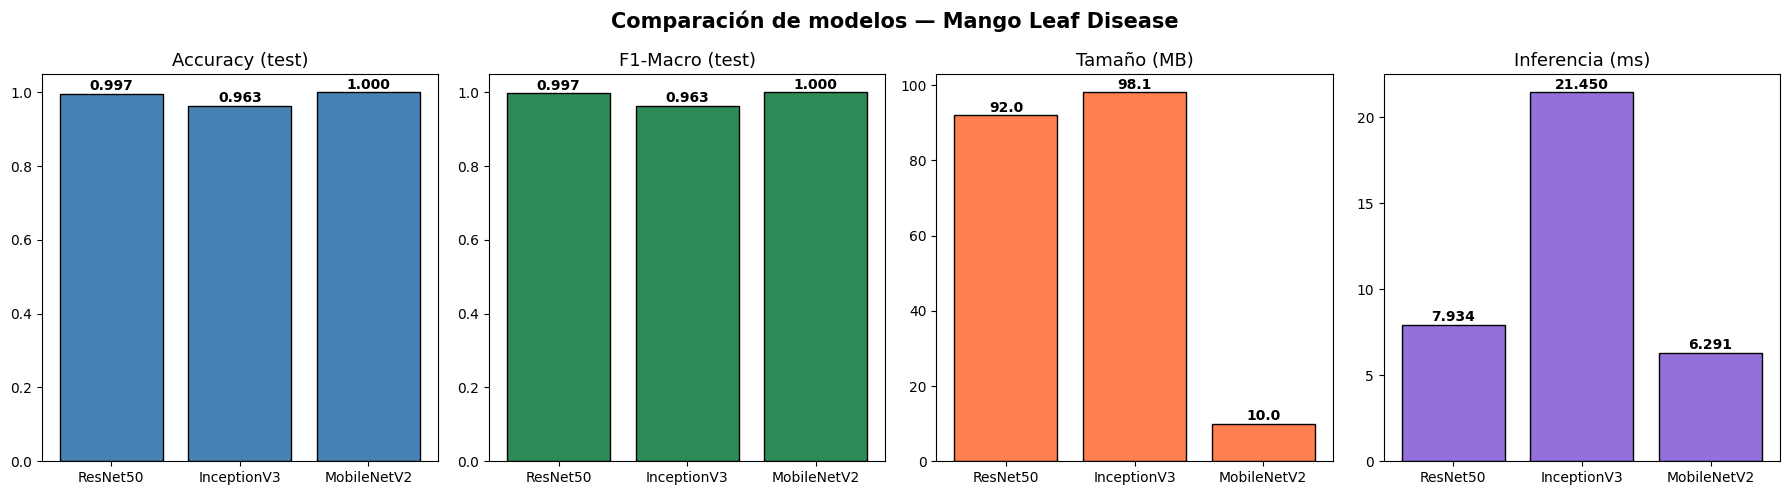

In [28]:
df_results = pd.DataFrame(results).set_index('model')
print("\nTabla comparativa de modelos:")
print(df_results.to_string())

# Gráfica de métricas
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['accuracy', 'f1_macro', 'size_mb', 'inference_ms']
titles  = ['Accuracy (test)', 'F1-Macro (test)', 'Tamaño (MB)', 'Inferencia (ms)']
colors  = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(df_results.index, df_results[metric], color=color, edgecolor='black')
    ax.set_title(title, fontsize=13)
    for i, v in enumerate(df_results[metric]):
        ax.text(i, v + max(df_results[metric]) * 0.01,
                f"{v:.3f}" if metric != 'size_mb' else f"{v:.1f}",
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Comparación de modelos — Mango Leaf Disease", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

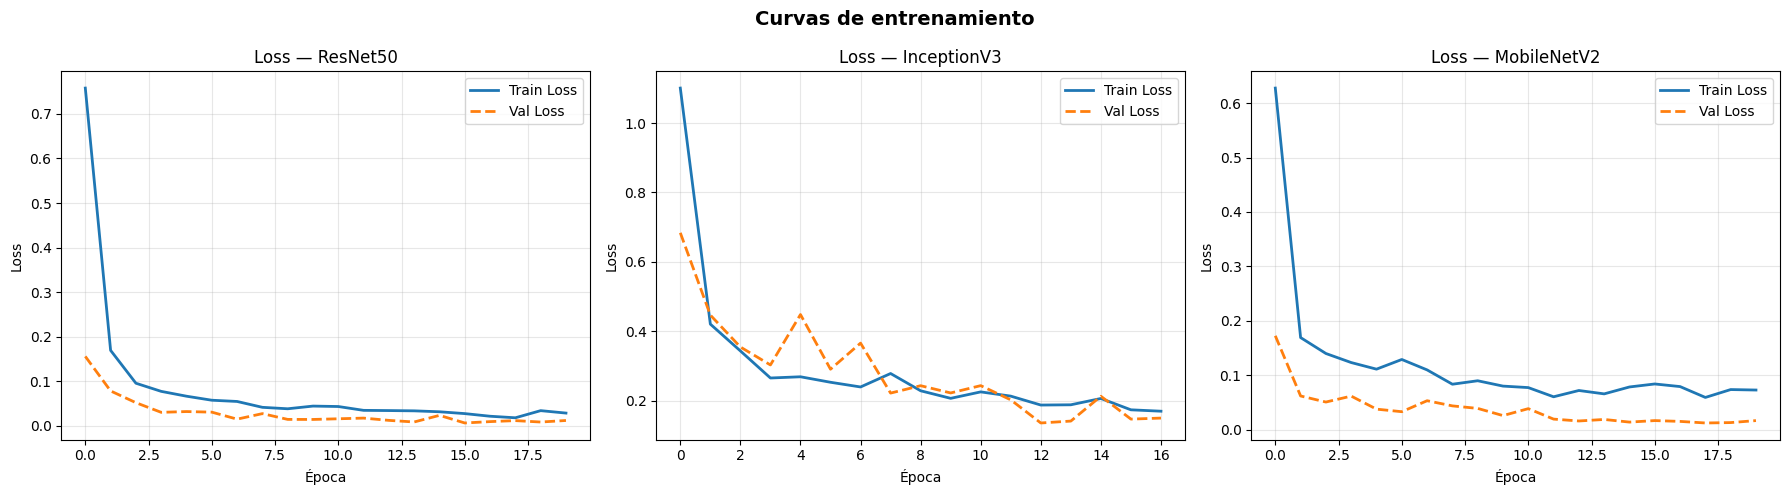

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name in zip(axes,
                           [resnet_history, inception_history, mobilenet_history],
                           ["ResNet50", "InceptionV3", "MobileNetV2"]):
    ax.plot(hist['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(hist['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
    ax.set_title(f"Loss — {name}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()